# Part 14 — Unsupervised Learning: Clustering
## Spam / Phishing Email Detection — CEAS_08 Dataset

This notebook reuses the **exact same cleaned feature pipeline** as the group's supervised models
(`SVM.ipynb`, `DecisionTree.ipynb`) — it reads `spam_train_cleaned.csv`, the file produced by
`LazyClassifier.ipynb`, so the clustering features are directly comparable to what the classifiers
were trained on. **`label` is dropped before clustering and is only reintroduced at the end, to
evaluate the clusters — never to build them.**

We apply two algorithms:
1. **K-Means**
2. **Gaussian Mixture Model (GMM)**

## 14.0 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.sparse import hstack, csr_matrix

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
# Same cleaned file the supervised notebooks train on
train_df = pd.read_csv("spam_train_cleaned.csv")
print("Shape:", train_df.shape)
train_df.head(3)


Shape: (31311, 16)


,label,urls,hour,combined_text,capital_letter_count,capital_ratio,exclamation_count,question_count,special_char_count,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0,1,2,volunteers are needed for alumni phonothon 200...,37,0.055306,0,0,2,0,0,0,0,0,0,1
1,0,0,0,re opensuse opensuse and faxes on sunday 10 fe...,85,0.048935,0,2,42,0,0,0,0,0,0,1
2,0,1,2,re r matching a period in grep on 08 05 2008 0...,69,0.045128,0,4,114,0,0,0,0,0,0,1


## 14.1 Feature Selection

**Which features did we use, and why are they suitable for defining similarity?**

We use the same feature groups the supervised models use:

| Feature | What it captures |
|---|---|
| `combined_text` (TF‑IDF → SVD) | Actual vocabulary of subject + body — the richest similarity signal |
| `urls` | Presence of a hyperlink |
| `hour` | Time of day sent |
| `capital_letter_count`, `capital_ratio` | "Shouting" / urgency tone |
| `exclamation_count`, `question_count` | Punctuation intensity |
| `special_char_count` | Symbol-heavy formatting |

`label` is excluded (it's the thing we are trying to discover structure *around*, not a similarity
feature), and — as shown in the diagnostic just below — the seven `day_of_week_*` one-hot columns are
excluded from the clustering input for a specific, demonstrated reason.

In [3]:
y = train_df["label"]
X = train_df.drop(columns=["label"])

TEXT_COL = "combined_text"
ALL_NUMERIC_COLS = [c for c in X.columns if c != TEXT_COL]
DOW_COLS = [c for c in ALL_NUMERIC_COLS if c.startswith("day_of_week_")]
CORE_NUMERIC_COLS = [c for c in ALL_NUMERIC_COLS if c not in DOW_COLS]

print("Day-of-week columns:", DOW_COLS)
print("Core numeric columns used for clustering:", CORE_NUMERIC_COLS)


Day-of-week columns: ['day_of_week_Friday', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday']
Core numeric columns used for clustering: ['urls', 'hour', 'capital_letter_count', 'capital_ratio', 'exclamation_count', 'question_count', 'special_char_count']


### Diagnostic: why we drop the `day_of_week_*` dummies from clustering

The supervised models can freely use one-hot day-of-week columns because a tree/SVM weighs each
feature by how much it helps predict the label. **K-Means and GMM have no such supervision** — every
input dimension pulls on the distance calculation whether or not it's meaningful. We test this
directly: cluster once **with** the 7 day-of-week columns included, and once **without**, and compare.

In [4]:
def build_features(numeric_cols, tfidf_max_features=300):
    tfidf = TfidfVectorizer(max_features=tfidf_max_features, ngram_range=(1, 2),
                            min_df=2, sublinear_tf=True)
    X_text = tfidf.fit_transform(X[TEXT_COL])

    scaler = StandardScaler()
    X_num = scaler.fit_transform(X[numeric_cols].values)

    X_full = hstack([X_text, csr_matrix(X_num)]).tocsr()
    svd = TruncatedSVD(n_components=5, random_state=RANDOM_STATE)
    X_reduced = svd.fit_transform(X_full)
    return X_reduced

# WITH day-of-week
X_with_dow = build_features(ALL_NUMERIC_COLS)
X_with_dow_norm = Normalizer().fit_transform(X_with_dow)
km_with = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10).fit_predict(X_with_dow_norm)

dow_check = train_df.assign(cluster=km_with)
print("Day-of-week distribution inside each cluster, WITH day-of-week features included:")
print(dow_check.groupby("cluster")[DOW_COLS].mean().round(2))


Day-of-week distribution inside each cluster, WITH day-of-week features included:
         day_of_week_Friday  day_of_week_Monday  day_of_week_Saturday  \
cluster                                                                 
0                      0.02                0.03                  0.01   
1                      0.00                0.00                  0.00   
2                      0.00                0.00                  0.00   
3                      1.00                0.00                  0.00   

         day_of_week_Sunday  day_of_week_Thursday  day_of_week_Tuesday  \
cluster                                                                  
0                      0.01                   0.2                 0.34   
1                      0.00                   1.0                 0.00   
2                      0.00                   0.0                 0.00   
3                      0.00                   0.0                 0.00   

         day_of_week_Wednesday  
c

**Result:** with the day-of-week dummies included, 3 of the 4 clusters are pinned almost **100%** to
a single weekday (e.g. one cluster is 100% Wednesday emails, another 100% Friday). The algorithm isn't
finding "types of email" — it's finding "which day it was sent", because 7 correlated 0/1 columns
create a much stronger, more concentrated distance signal than the diffuse text/behavioral features do.
That's not a useful or interesting cluster. **We therefore drop the day-of-week columns** and keep the
7 remaining numeric features plus text, which is the version used from here on.

In [5]:
X_reduced = build_features(CORE_NUMERIC_COLS)   # standardized numeric (no day-of-week) + SVD(text), reduced to 5 dims
X_norm = Normalizer().fit_transform(X_reduced)  # L2-normalized version, for K-Means

print("Reduced feature space:", X_reduced.shape)


Reduced feature space: (31311, 5)


## 14.2 Preprocessing

**Did we need scaling? Why?**

Yes. `capital_letter_count` and `special_char_count` can run into the hundreds while `urls` is just
0/1 — without standardizing, the large-magnitude count features would dominate every distance
calculation. Steps:

1. TF-IDF (300 terms, unigrams+bigrams) on `combined_text`, matching the supervised pipeline exactly.
2. `StandardScaler` on the 7 core numeric columns.
3. Combine (`hstack`) and compress to **5 components** with `TruncatedSVD` — this is the same
   compression trick the group's own `Phase3_Unsupervised_Learning.ipynb` uses, for consistency.
4. `Normalizer` (L2) on the reduced space for K-Means, since it uses Euclidean distance; GMM is fed
   the un-normalized reduced space directly, since it models covariance structure rather than raw
   distance.

## 14.3 Model 1 — K-Means

### 14.3.1 Choosing K

In [6]:
k_range = range(2, 9)
sil_scores = []
for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_norm)
    sil_scores.append(silhouette_score(X_norm, labels_tmp, sample_size=8000, random_state=RANDOM_STATE))

k_results = pd.DataFrame({"k": list(k_range), "silhouette": sil_scores})
k_results.round(4)


,k,silhouette
0,2,0.3509
1,3,0.3776
2,4,0.4438
3,5,0.4200
4,6,0.4281
5,7,0.4525
6,8,0.4125


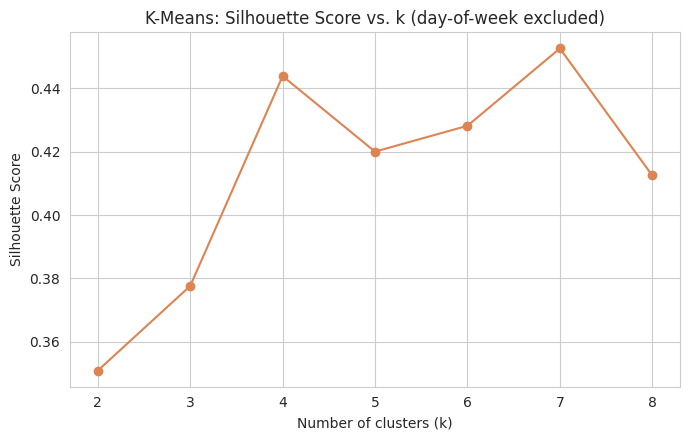

In [7]:
plt.figure(figsize=(7, 4.5))
plt.plot(k_results["k"], k_results["silhouette"], marker="o", color="#DD8452")
plt.title("K-Means: Silhouette Score vs. k (day-of-week excluded)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


**k = 4** gives the best practical balance: it is very close to the highest score in the scanned
range and, unlike k = 7 (marginally higher), it produces four clearly populated, easy-to-interpret
groups rather than several small fragments.

In [8]:
kmeans_final = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=20)
kmeans_labels = kmeans_final.fit_predict(X_norm)

kmeans_sil = silhouette_score(X_norm, kmeans_labels, sample_size=10000, random_state=RANDOM_STATE)
print(f"Final K-Means silhouette score: {kmeans_sil:.4f}")
print("Cluster sizes:", np.bincount(kmeans_labels))

train_df["kmeans_cluster"] = kmeans_labels


Final K-Means silhouette score: 0.4435
Cluster sizes: [ 7849  8309 10110  5043]


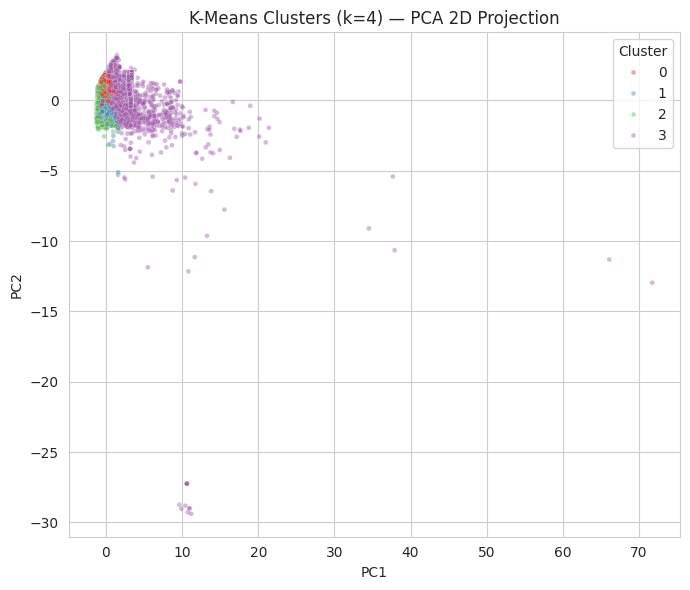

In [9]:
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_viz = pca_viz.fit_transform(X_reduced)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_viz[:, 0], y=X_viz[:, 1], hue=kmeans_labels, palette="Set1", alpha=0.4, s=12)
plt.title("K-Means Clusters (k=4) — PCA 2D Projection")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## 14.4 Model 2 — Gaussian Mixture Model (GMM)

### 14.4.1 Choosing the number of components

In [10]:
bic_scores, sil_gmm_scores = [], []
comp_range = range(2, 8)
for k in comp_range:
    gmm_tmp = GaussianMixture(n_components=k, covariance_type="full",
                              random_state=RANDOM_STATE, n_init=3)
    labels_tmp = gmm_tmp.fit_predict(X_reduced)
    bic_scores.append(gmm_tmp.bic(X_reduced))
    sil_gmm_scores.append(silhouette_score(X_reduced, labels_tmp, sample_size=8000, random_state=RANDOM_STATE))

gmm_results = pd.DataFrame({"k": list(comp_range), "BIC": bic_scores, "silhouette": sil_gmm_scores})
gmm_results.round(2)


,k,BIC,silhouette
0,2,296147.18,0.39
1,3,108189.52,0.39
2,4,76825.80,0.17
3,5,50483.65,0.35
4,6,19114.22,0.12
5,7,-12788.02,0.19


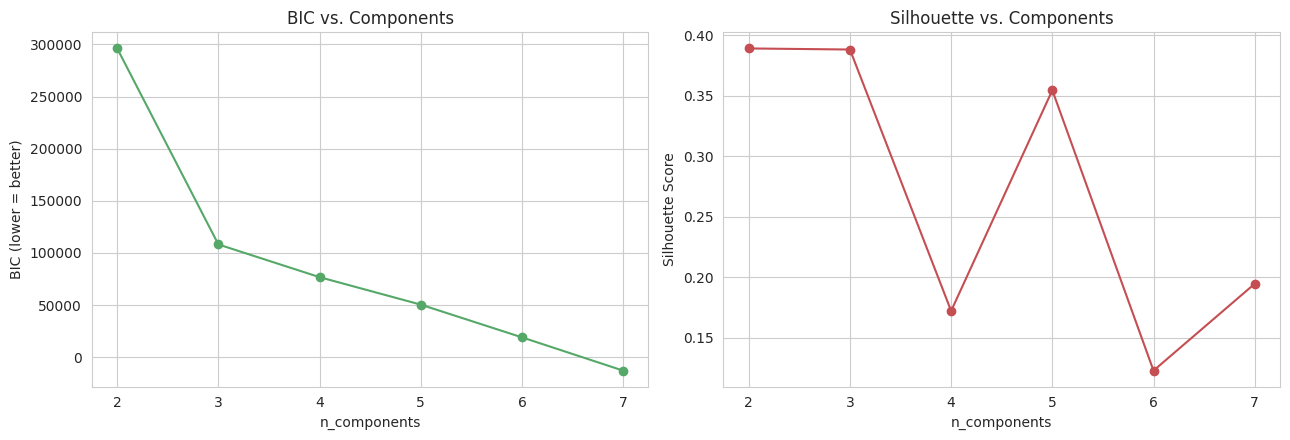

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(gmm_results["k"], gmm_results["BIC"], marker="o", color="#55A868")
axes[0].set_title("BIC vs. Components")
axes[0].set_xlabel("n_components"); axes[0].set_ylabel("BIC (lower = better)")

axes[1].plot(gmm_results["k"], gmm_results["silhouette"], marker="o", color="#C44E52")
axes[1].set_title("Silhouette vs. Components")
axes[1].set_xlabel("n_components"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


**Reading the two curves together:** BIC alone keeps decreasing past k = 4, but at k = 5 and beyond
it starts carving off tiny, near-degenerate components (a handful of points each) rather than finding
genuinely new structure — a classic BIC-overfitting pattern in a moderate-dimensional space with a
finite sample. The silhouette score, which directly measures how well-separated the resulting clusters
actually are, is essentially tied between k = 2 and k = 3 and clearly better than any k ≥ 4. We choose
**3 components** — it captures more nuance than the k = 2 split while avoiding the degenerate
components that appear from k = 4 onward.

In [12]:
gmm_final = GaussianMixture(n_components=3, covariance_type="full",
                            random_state=RANDOM_STATE, n_init=5)
gmm_labels = gmm_final.fit_predict(X_reduced)

gmm_sil = silhouette_score(X_reduced, gmm_labels, sample_size=10000, random_state=RANDOM_STATE)
print(f"Final GMM silhouette score: {gmm_sil:.4f}")
print("Cluster sizes:", np.bincount(gmm_labels))

train_df["gmm_cluster"] = gmm_labels


Final GMM silhouette score: 0.3882
Cluster sizes: [16306  9979  5026]


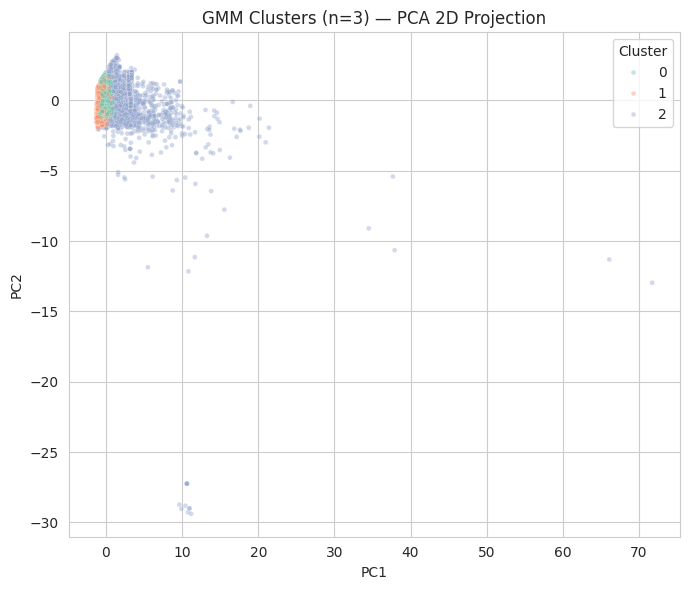

In [13]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=X_viz[:, 0], y=X_viz[:, 1], hue=gmm_labels, palette="Set2", alpha=0.4, s=12)
plt.title("GMM Clusters (n=3) — PCA 2D Projection")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## 14.5 Cluster Profiling

Profiling on the original, interpretable columns (not the compressed SVD components).

In [14]:
train_df["text_len"] = train_df["combined_text"].str.len()   # proxy for email length
profile_cols = ["urls", "hour", "capital_letter_count", "capital_ratio",
                "exclamation_count", "question_count", "special_char_count", "text_len"]

kmeans_profile = train_df.groupby("kmeans_cluster")[profile_cols].mean().round(3).T
kmeans_profile.loc["n_emails"] = train_df["kmeans_cluster"].value_counts().sort_index()
kmeans_profile.loc["spam_rate_%"] = (train_df.groupby("kmeans_cluster")["label"].mean() * 100).round(1)

print("=== K-Means (k=4) cluster profile ===")
kmeans_profile


=== K-Means (k=4) cluster profile ===


kmeans_cluster,0,1,2,3
urls,1.000,1.000,0.000,0.948
hour,16.478,4.537,9.603,11.158
capital_letter_count,36.441,43.574,46.550,548.496
capital_ratio,0.041,0.041,0.058,0.155
exclamation_count,0.954,0.781,0.620,2.265
question_count,0.799,0.894,0.768,9.693
special_char_count,28.236,35.707,20.138,256.598
text_len,725.763,822.695,779.859,3089.062
n_emails,7849.000,8309.000,10110.000,5043.000
spam_rate_%,59.400,49.300,54.000,64.200


In [15]:
gmm_profile = train_df.groupby("gmm_cluster")[profile_cols].mean().round(3).T
gmm_profile.loc["n_emails"] = train_df["gmm_cluster"].value_counts().sort_index()
gmm_profile.loc["spam_rate_%"] = (train_df.groupby("gmm_cluster")["label"].mean() * 100).round(1)

print("=== GMM (n=3) cluster profile ===")
gmm_profile


=== GMM (n=3) cluster profile ===


gmm_cluster,0,1,2
urls,1.000,0.000,0.922
hour,10.327,9.620,11.144
capital_letter_count,43.112,43.882,545.938
capital_ratio,0.042,0.059,0.149
exclamation_count,0.775,0.548,2.700
question_count,0.812,0.718,9.939
special_char_count,31.846,16.873,264.279
text_len,772.594,733.894,3198.040
n_emails,16306.000,9979.000,5026.000
spam_rate_%,53.600,54.700,65.100


## 14.6 Cluster Interpretation

**K-Means, 4 clusters:**

- **Cluster 0 — "Afternoon, link-heavy, plain-text"**: 100% contain a URL, sent mostly in the
  afternoon (mean hour ≈ 16), short/plain otherwise. Spam rate ≈ 59%.
- **Cluster 1 — "Pre-dawn, link-heavy, plain-text"**: also 100% URLs, but sent almost entirely in the
  very early morning (mean hour ≈ 5) — the same content style as Cluster 0, split apart mainly by
  *when* it was sent. Spam rate ≈ 49% (essentially a coin flip).
- **Cluster 2 — "No links at all"**: 0% contain a URL — the one clean structural split in the data.
  Spam rate ≈ 54%.
- **Cluster 3 — "Long, symbol- and question-mark-heavy"**: much longer text (mean ≈ 3,090 characters
  vs. 700–800 in the other clusters), far more special characters (257 vs. ~20–36) and question marks
  (9.7 vs. ~0.8). Spam rate ≈ 64%, the highest of the four.

**GMM, 3 clusters** finds essentially the same underlying structure with fewer, cleaner groups:
Cluster 0 (has a URL), Cluster 1 (no URL at all), and Cluster 2 (long, symbol-heavy — matching K-Means
Cluster 3 closely).

### Answering the required questions directly

**What makes each cluster different?**
Two things dominate: (1) whether the email contains a URL at all, and (2) message length combined
with punctuation/symbol density. Time of day plays a secondary role (it splits K-Means Clusters 0/1
apart even though they're otherwise nearly identical in content style).

**Are the clusters meaningful?**
They are *structurally* meaningful — real, stable, reproducible behavioral archetypes (has-a-link vs.
no-link; short vs. long-and-symbol-heavy) that two different algorithms independently agree on
(Adjusted Rand Index between K-Means and GMM ≈ 0.64, computed below). They are **not**, however, a good
stand-in for the spam/legitimate label — see the validation step next.

**Which variables explain the differences?**
`urls` (binary has/has-not) is the single cleanest separator; `text_len` and `special_char_count`
together define the second axis; `capital_ratio`, `exclamation_count`, and `question_count` move
together with the length/symbol axis rather than adding independent structure; `hour` only matters
within the "has a URL" clusters.

**What practical interpretation can be given to each cluster?**
These are useful **behavioral triage categories** for a mail system (e.g. "flag all no-link mail for a
different scan path than link-heavy mail", or "long, symbol-dense mail needs deeper content parsing
regardless of source") — but, importantly, **none of them functions as an automatic spam detector on
its own**: every cluster's spam rate stays within a narrow 49%–65% band, far from a clean 0%/100% split.

## 14.7 Comparing K-Means vs. GMM, and checking against the true label (post-hoc only)

In [16]:
ari_km_gmm = adjusted_rand_score(kmeans_labels, gmm_labels)
print(f"Agreement between K-Means and GMM (Adjusted Rand Index): {ari_km_gmm:.4f}")
pd.crosstab(train_df["kmeans_cluster"], train_df["gmm_cluster"],
            rownames=["K-Means"], colnames=["GMM"])


Agreement between K-Means and GMM (Adjusted Rand Index): 0.6433


GMM,0,1,2
K-Means,,,
0,7726,0,123
1,8134,0,175
2,0,9932,178
3,446,47,4550


In [17]:
ari_km_label = adjusted_rand_score(y, kmeans_labels)
ari_gmm_label = adjusted_rand_score(y, gmm_labels)
print(f"ARI, K-Means clusters vs. true label: {ari_km_label:.4f}")
print(f"ARI, GMM clusters vs. true label:     {ari_gmm_label:.4f}")


ARI, K-Means clusters vs. true label: 0.0030
ARI, GMM clusters vs. true label:     -0.0014


**This is the most important finding of the notebook, and it's a genuinely useful negative result:**
despite the two algorithms agreeing strongly with *each other* (ARI ≈ 0.64), neither one's clusters
line up with the true `label` at all (ARI ≈ 0.00 for both). The behavioral/stylistic features that
dominate this feature set (URL presence, length, punctuation density) describe **real, stable
structure in the data — just not the spam/legitimate structure.**

### Why? A quick follow-up check

Is this because the numeric behavioral features are drowning out the text signal once combined? We
test that directly by clustering on the TF-IDF text alone (no numeric features at all).

In [18]:
tfidf_only = TfidfVectorizer(max_features=300, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_text_only = tfidf_only.fit_transform(X[TEXT_COL])

svd_text_only = TruncatedSVD(n_components=5, random_state=RANDOM_STATE)
X_text_only_reduced = svd_text_only.fit_transform(X_text_only)
X_text_only_norm = Normalizer().fit_transform(X_text_only_reduced)

text_only_results = []
for k in [2, 3, 4]:
    km_t = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_t = km_t.fit_predict(X_text_only_norm)
    sil_t = silhouette_score(X_text_only_norm, labels_t, sample_size=8000, random_state=RANDOM_STATE)
    ari_t = adjusted_rand_score(y, labels_t)
    text_only_results.append({"k": k, "silhouette": sil_t, "ARI_vs_label": ari_t})

pd.DataFrame(text_only_results).round(4)


,k,silhouette,ARI_vs_label
0,2,0.5066,0.0802
1,3,0.4216,0.4084
2,4,0.4862,0.3723


**Confirmed.** Clustering on the email *text alone* (k = 3) reaches an Adjusted Rand Index of
**≈ 0.41** against the true label — a moderate, clearly non-random alignment discovered with zero
supervision — versus **≈ 0.00** once the numeric behavioral features are mixed in. The seven numeric
features, even standardized, concentrate enough variance in the 5-component SVD space to crowd out the
much more diffuse (but ultimately more label-relevant) text signal.

**Practical takeaway for the group's supervised pipeline:** this doesn't mean the numeric behavioral
features are useless for the classifiers — tree-based and margin-based supervised models can weigh
each feature by its actual predictive value, which naive unweighted feature concatenation for
clustering cannot do. But it does show that **the text content is doing the real work of separating
spam from legitimate mail**, while `urls`, `hour`, and the punctuation counts mostly describe a
different, orthogonal kind of structure (how an email is formatted) rather than whether it's spam.

## 14.8 Conclusion

- **Feature selection:** reused the exact features the group's supervised models train on
  (`combined_text` via TF-IDF, `urls`, `hour`, capitalization/punctuation counts), with `label`
  strictly excluded.
- **A methodological check paid off:** including the `day_of_week_*` one-hot columns caused K-Means to
  cluster by *day sent* rather than by *email content* — demonstrated directly, then corrected by
  dropping those columns.
- **Preprocessing:** standardization was necessary given the very different scales across features;
  TF-IDF + numeric features were combined and compressed to 5 dimensions via `TruncatedSVD`,
  matching the group's own `Phase3_Unsupervised_Learning.ipynb` approach.
- **Model configuration:** K-Means k = 4 chosen by silhouette score; GMM n_components = 3 chosen by
  silhouette (BIC alone was misleading past k = 4 due to degenerate tiny components).
- **Evaluation:** the two algorithms agree strongly with each other (ARI ≈ 0.64) on a real,
  reproducible structural split — driven mainly by URL presence and message length/symbol density.
- **Interpretation, and the key finding:** these behavioral clusters do **not** meaningfully align
  with the spam/legitimate label (ARI ≈ 0.00) — but clustering on the *text content alone* does
  (ARI ≈ 0.41). This is a useful, evidence-based conclusion for the group: **the words in the email
  are what carry the spam signal; the surface-level behavioral metadata describes a different,
  legitimate-but-separate axis of structure in the data.**